<a href="https://colab.research.google.com/github/wide-bridge/AIFFEL_quest_eng/blob/master/M2_Misclassification_XAI_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔎 Day 6 — M2. 오분류 사례 분석 & XAI 신뢰성 (2H)

**한국AX산업협회 의료 AI 개발 실무 교육과정 — Day 6**

> **"맞춘 모델이 아니라 틀린 사례가 모델을 말한다"**
>
> M1에서 만든 Grad-CAM 도구를 손에 쥐었다 → 이걸 의사결정 검증에 어떻게 쓸지를 다룬다.

| 항목 | 내용 |
|------|------|
| 런타임 | Google Colab (T4 GPU) |
| 모델 | Day 5 `day5_resnet50_best.pt` (폐렴 이진분류 ResNet50) |
| 데이터 | Day 5 M4 `test_predictions.csv` + RSNA Pneumonia test split (bbox annotation 포함) |
| 실습 4종 | 오분류 추출+Grad-CAM · bbox 시각 비교 · Sanity check · Pointing Game + 백본 비교 |

---

## 0. 환경 설정

In [1]:
# ============================================================
# 📦 패키지 설치
# ============================================================
# Google Colab에서 실행하세요.
# GPU 설정: Runtime > Change runtime type > T4 GPU

!pip install -q torch torchvision matplotlib numpy pandas opencv-python
!pip install -q grad-cam  # pytorch-grad-cam (M1에서 hook 원리 학습 완료 → M2부터는 검증된 라이브러리 사용)
!pip install medmnist

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 56.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.4 MB/s eta 0:00:00


In [2]:
# ──────────────────────────────────────────────────────────
# 디바이스 설정 (DEVICE — 대문자 변수, 노트북 전체에서 사용)
# ──────────────────────────────────────────────────────────
import torch

def get_device():
    """Colab(CUDA) → Mac(MPS) → CPU 순으로 사용 가능한 디바이스를 반환"""
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")

DEVICE = get_device()
print(f"사용 디바이스: {DEVICE}")

사용 디바이스: cuda


✅ 폰트 설정 완료: ['NanumGothic']


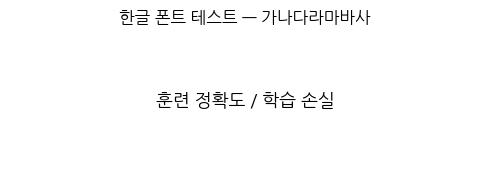

In [3]:
# 한글 폰트 자동 설정 함수 (공통 스킬 표준 함수)
import subprocess, os, glob
import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def setup_korean_font():
    is_colab = False
    try:
        import google.colab; is_colab = True
    except ImportError:
        pass

    if is_colab:
        FONT_PATH = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
        if not os.path.exists(FONT_PATH):
            subprocess.run(["apt-get", "install", "-y", "fonts-nanum"],
                           check=True, capture_output=False)
        for f in glob.glob(os.path.join(mpl.get_cachedir(), "*.json")):
            os.remove(f)
        if os.path.exists(FONT_PATH):
            fm.fontManager.addfont(FONT_PATH)
            plt.rcParams["font.family"] = "NanumGothic"
        else:
            plt.rcParams["font.family"] = "sans-serif"
        plt.rcParams["axes.unicode_minus"] = False
        print(f"✅ 폰트 설정 완료: {plt.rcParams['font.family']}")
    else:
        import platform
        os_name = platform.system()
        font_name = 'AppleGothic'   if os_name == 'Darwin'  else \
                    'Malgun Gothic' if os_name == 'Windows' else 'NanumGothic'
        available = any(font_name.lower() in f.name.lower() for f in fm.fontManager.ttflist)
        if available:
            plt.rcParams['font.family'] = font_name
        plt.rcParams['axes.unicode_minus'] = False
    fig, ax = plt.subplots(figsize=(5, 2))
    ax.set_title("한글 폰트 테스트 — 가나다라마바사")
    ax.text(0.5, 0.5, "훈련 정확도 / 학습 손실", ha="center", fontsize=13)
    ax.axis("off"); plt.tight_layout(); plt.show()

setup_korean_font()

In [4]:
# 체크포인트 환경 설정 (Colab → Drive mount / 로컬 그대로)
# Day 5 산출물 day5_resnet50_best.pt를 로드하기 위한 사전 설정.
# Colab이면 Google Drive를 mount해서 Drive 안의 체크포인트에 접근.

def setup_ckpt_env():
    is_colab = False
    try:
        import google.colab
        is_colab = True
    except ImportError:
        pass

    import os
    if is_colab:
        from google.colab import drive
        drive.mount('/content/drive')
        # ckpt_dir = '/content/drive/MyDrive/Colab Notebooks/의료_AI개발_실무/Day6/checkpoints'
        ckpt_dir = '/content/drive/MyDrive/의료AI/checkpoints'
    else:
        ckpt_dir = os.path.join(os.getcwd(), 'checkpoints')
    print(f"✅ 체크포인트 디렉토리: {ckpt_dir}")
    return ckpt_dir

CKPT_DIR = setup_ckpt_env()

Mounted at /content/drive
✅ 체크포인트 디렉토리: /content/drive/MyDrive/의료AI/checkpoints


---

## 📖 Part 1 — 왜 오분류를 들여다보는가

### Confusion matrix 4분면

| 정답 \ 예측 | 정상 (0) | 폐렴 (1) |
|-----------|---------|---------|
| 정상 | **TN** (정상→정상) | **FP** (정상→폐렴, over-call) |
| 폐렴 | **FN** (폐렴→정상, miss) | **TP** (폐렴→폐렴) |

- **FP**: 정상을 폐렴이라 오인 — 임상에서는 불필요한 후속 검사 부담
- **FN**: 폐렴을 놓침 — 임상에서 가장 치명적

### Shortcut Learning (검증된 사례 2건)

| 사례 | 출처 | 발견 |
|------|------|-----|
| COVID X-ray shortcut | DeGrave, Janizek, Lee (**2021**), *Nat. Mach. Intell.* 3:610–619 | 영상 가장자리·라벨·자세 단서에 반응, 외부 데이터 성능 급락 |
| 병원별 일반화 실패 | Zech et al. (**2018**), *PLOS Medicine* 15(11):e1002683 | 한 병원 학습 → 다른 병원에서 AUC 0.93→0.75 |

### Sanity Check (Adebayo 2018)

> **무작위 가중치 모델의 saliency가 학습된 모델과 비슷하면, 그 saliency는 의심해야 한다.**
>
> Adebayo et al., "Sanity Checks for Saliency Maps", **NeurIPS 2018** (arXiv:1810.03292)

- ⚠️ **필요조건일 뿐 충분조건이 아니다** — A ≠ B 라고 그 saliency가 임상적으로 옳음을 보장하진 않는다.

### Pointing Game (정량 평가)

> Grad-CAM **peak(argmax) 좌표**가 정답 bbox 내부에 들어가면 **hit**.
> 전체 양성 사례 중 hit 비율 = **hit rate**.
>
> 원전: Zhang et al., "Top-Down Neural Attention by Excitation Backprop",
> **ECCV 2016** (arXiv:1608.00507) / IJCV 2018 확장판. 본 실습은 단순화 버전.

---

## 📂 Day 5 산출물 로드 + 데이터 준비

> ⚠️ **강의 직전 확인 필수** — 본 셀은 Day 5 산출물(`day5_resnet50_best.pt`,
> `day5_model.py`, `test_predictions.csv`, RSNA bbox annotation)이 Google Drive
> 공유 폴더에 사전 업로드돼 있다고 가정합니다.
>
> bbox annotation의 컬럼명·좌표계(좌상단 vs 중심 좌표 / 원본 vs 224×224)는
> 강의 직전 재확인이 필요합니다. 본 노트북은 다음 컬럼명 가정:
> `image_id`, `x`, `y`, `width`, `height` (좌상단 + 너비·높이, 224×224 좌표계).

In [5]:
# ============================================================
# Day 5 산출물 로드 — 체크포인트만 필요 (예측/bbox는 실시간 생성)
# ============================================================
import os, sys, numpy as np, pandas as pd
import cv2
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as T

# 위에서 설정한 CKPT_DIR 사용 (Colab: Drive / 로컬: 노트북 옆 checkpoints/)
MODEL_PATH = os.path.join(CKPT_DIR, 'day5_resnet50_best.pt')
print('MODEL_PATH:', MODEL_PATH, '— exists?', os.path.exists(MODEL_PATH))
print('ℹ️ 예측 결과(preds_df)와 bbox는 외부 CSV 없이 ChestMNIST + 체크포인트로 직접 생성합니다.')

MODEL_PATH: /content/drive/MyDrive/의료AI/checkpoints/day5_resnet50_best.pt — exists? True
ℹ️ 예측 결과(preds_df)와 bbox는 외부 CSV 없이 ChestMNIST + 체크포인트로 직접 생성합니다.


In [6]:
# ============================================================
# 모델 로드 — Day 5에서 학습한 ResNet50 (폐렴 이진분류)
# ============================================================
def build_resnet50_binary(in_ch=1, num_classes=2):
    """Day 5 컨벤션: conv1 → 1ch, fc → 2 클래스."""
    m = models.resnet50(weights=None)
    if in_ch == 1:
        m.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    m.fc = nn.Linear(2048, num_classes)
    return m

model = build_resnet50_binary().to(DEVICE)
try:
    state = torch.load(MODEL_PATH, map_location=DEVICE)
    if isinstance(state, dict):
        for k in ('model_state_dict', 'state_dict'):
            if k in state:
                state = state[k]
                break
    model.load_state_dict(state, strict=False)
    print('✅ Day 5 best 체크포인트 로드 완료')
except Exception as e:
    print(f'⚠️ 체크포인트 로드 실패: {e}\n   → ImageNet pretrained로 fallback')
    m_pre = models.resnet50(weights='IMAGENET1K_V2')
    model.conv1.weight.data.copy_(m_pre.conv1.weight.data.mean(dim=1, keepdim=True))
model.eval()
print(f'   파라미터: {sum(p.numel() for p in model.parameters()):,}')

✅ Day 5 best 체크포인트 로드 완료
   파라미터: 23,505,858


In [7]:
# ============================================================
# 실시간 추론 → preds_df 생성  +  폐 영역 휴리스틱 bbox
# ============================================================
# Day 5와 동일한 ChestMNIST test split에 체크포인트를 적용해 예측을 얻고,
# ROI annotation은 ChestMNIST에 없으므로 좌우 폐 영역 휴리스틱 bbox로 대체합니다.
# (실제 RSNA / NIH ChestX-ray8 같이 bbox가 있는 데이터셋이면 그 좌표를 그대로 쓰면 됨)
from medmnist import ChestMNIST

test_ds = ChestMNIST(split='test', download=True, size=64)
print(f'ChestMNIST test split: {len(test_ds)}개')

# 데모 시간 단축을 위해 앞쪽 N장만 추론
N_DEMO = 200

def _prep_tensor_from_pil(pil_img, size=224):
    """Day 5 컨벤션: 1ch, /255, bilinear upscale"""
    arr = np.array(pil_img, dtype=np.float32)
    if arr.ndim == 3:
        arr = arr[:, :, 0]
    t = torch.from_numpy(arr / 255.0).float().unsqueeze(0).unsqueeze(0)
    return F.interpolate(t, size=(size, size), mode='bilinear', align_corners=False)

# === 체크포인트 모델로 실시간 추론 ===
rows = []
model.eval()
with torch.no_grad():
    for i in range(min(N_DEMO, len(test_ds))):
        pil_img, lbl_arr = test_ds[i]
        true = int(np.array(lbl_arr).sum() > 0)
        t = _prep_tensor_from_pil(pil_img).to(DEVICE)
        logits = model(t)
        prob = F.softmax(logits, dim=1)[0, 1].item()
        pred = int(prob > 0.5)
        rows.append({
            'image_id': f'cm_{i:04d}',
            'idx': i,
            'true': true,
            'pred': pred,
            'prob_pneumonia': prob,
        })
preds_df = pd.DataFrame(rows)

tp = ((preds_df.true == 1) & (preds_df.pred == 1)).sum()
fp = ((preds_df.true == 0) & (preds_df.pred == 1)).sum()
fn = ((preds_df.true == 1) & (preds_df.pred == 0)).sum()
tn = ((preds_df.true == 0) & (preds_df.pred == 0)).sum()
print(f'예측 완료: {len(preds_df)}건  (TP={tp}, FP={fp}, FN={fn}, TN={tn})')

# === bbox: ChestMNIST는 ROI annotation 없음 → 좌우 폐 영역 휴리스틱 ===
LUNG_BBOXES_224 = [
    (40,  60, 70, 110),   # 좌측 폐 (관찰자 기준 우측)
    (114, 60, 70, 110),   # 우측 폐 (관찰자 기준 좌측)
]
bbox_rows = []
for r in preds_df.itertuples():
    if r.true == 1:
        for (x, y, w, h) in LUNG_BBOXES_224:
            bbox_rows.append({'image_id': r.image_id, 'x': x, 'y': y, 'width': w, 'height': h})
bbox_df = pd.DataFrame(bbox_rows)
print(f'bbox: {len(bbox_df)}건 (양성 {(preds_df.true==1).sum()}장 × 좌우 폐 영역 2개)')
preds_df.head()

100%|██████████| 402M/402M [00:31<00:00, 12.7MB/s]


ChestMNIST test split: 22433개
예측 완료: 200건  (TP=66, FP=48, FN=27, TN=59)
bbox: 186건 (양성 93장 × 좌우 폐 영역 2개)


,image_id,idx,true,pred,prob_pneumonia
0,cm_0000,0,0,0,0.469476
1,cm_0001,1,0,0,0.438259
2,cm_0002,2,1,0,0.435366
3,cm_0003,3,0,0,0.467755
4,cm_0004,4,0,0,0.398787


In [8]:
# ============================================================
# 이미지 로더 — ChestMNIST에서 인덱스로 직접 로드 (Day 5 컨벤션: 1ch, /255)
# ============================================================
def load_image_224(image_id):
    """image_id ('cm_NNNN') → ((1,1,224,224) tensor on DEVICE, (224,224) display numpy)"""
    idx = int(preds_df.loc[preds_df['image_id'] == image_id, 'idx'].iloc[0])
    pil_img, _ = test_ds[idx]
    arr = np.array(pil_img, dtype=np.float32)
    if arr.ndim == 3:
        arr = arr[:, :, 0]
    t = torch.from_numpy(arr / 255.0).float().unsqueeze(0).unsqueeze(0)
    t224 = F.interpolate(t, size=(224, 224), mode='bilinear', align_corners=False).to(DEVICE)
    disp = t224[0, 0].cpu().numpy()
    return t224, disp

# 테스트
t0, d0 = load_image_224(preds_df.iloc[0]['image_id'])
print('tensor shape:', t0.shape, '/ display shape:', d0.shape)

tensor shape: torch.Size([1, 1, 224, 224]) / display shape: (224, 224)


### Grad-CAM++ — `pytorch-grad-cam` 라이브러리 사용

M1에서 forward / backward hook으로 GradCAM을 직접 구현하며 **원리**를 학습했고,
그 끝에서 **GradCAM++** 가 작은 병변·좁은 hotspot에서 더 선명한 heatmap을 만든다는 것을
torchcam 비교 실험으로 확인했다 (M1 §6).

M2부터는 그 결론을 받아 **GradCAM++** 를 기본으로 사용한다.
라이브러리는 검증된 `pytorch-grad-cam` (`grad-cam` 패키지) 을 사용한다.

- 함수 이름은 `gradcam_one` 그대로 (호출부 호환), **내부 구현만 `GradCAMPlusPlus`** 로 교체.
- 라이브러리가 hook 등록/해제·정규화·입력 크기 리사이즈를 알아서 처리한다.

In [9]:
# ============================================================
# Grad-CAM++ (pytorch-grad-cam wrapper)
# ============================================================
# 시그니처는 M1과 동일: (model, image_tensor, target_class, target_layer) → (224,224) heatmap
# 내부 알고리즘은 GradCAM++ (M1 §6에서 작은 병변에 더 유리하다고 결론낸 변형)
from pytorch_grad_cam import GradCAMPlusPlus as _PGC_GradCAMPP
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

def gradcam_one(model, image_tensor, target_class, target_layer):
    """image_tensor: (1, 1, 224, 224) — target_layer: ex. model.layer4
    Returns: heatmap (224, 224) numpy, normalized [0, 1]  (내부적으로 GradCAM++)
    """
    model.eval()
    image_tensor = image_tensor.to(DEVICE)
    with _PGC_GradCAMPP(model=model, target_layers=[target_layer]) as cam_extractor:
        cam = cam_extractor(input_tensor=image_tensor,
                            targets=[ClassifierOutputTarget(target_class)])
    return cam[0]  # (224, 224) numpy, 라이브러리가 [0,1] 정규화 + 입력 크기로 리사이즈 처리

print('✅ gradcam_one 정의 완료 (pytorch-grad-cam · GradCAM++ wrapper)')

✅ gradcam_one 정의 완료 (pytorch-grad-cam · GradCAM++ wrapper)


---

# 🎯 실습 1 — 오분류 사례 추출과 Grad-CAM 분석 [강사 시연]

**목표**: FP/FN 사례를 분리해 추출하고 Grad-CAM을 적용해 본다.

**사용 라이브러리**: `pandas`, `matplotlib`, `cv2`, `torch`, `torchvision.models`

| 단계 | 내용 |
|------|------|
| 1-1 | Confusion matrix 재시각화 (Day 5 M4 결과) |
| 1-2 | FP / FN 인덱스 추출 |
| 1-3 | 사례별 예측 확률 분포 — 확신 있게 틀린 vs 0.5 부근 |
| 1-4 | FN 사례 Grad-CAM 일괄 적용 |
| 1-5 | FP 사례 Grad-CAM 일괄 적용 |
| 1-6 | 결과 토의 — 가설 수준 |

**결과물**: FP 상위 5장, FN 상위 5장의 Grad-CAM overlay grid + 토의 메모

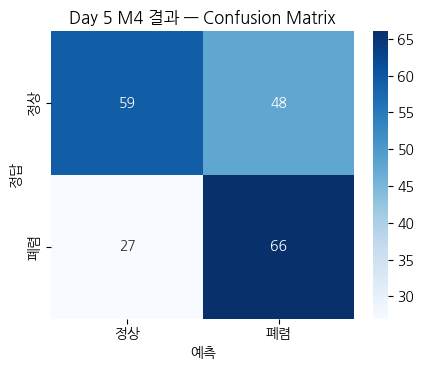

[[59 48]
 [27 66]]


In [10]:
# ============================================================
# 1-1: Confusion matrix 재시각화
# ============================================================
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(preds_df['true'], preds_df['pred'])
fig, ax = plt.subplots(figsize=(4.5, 3.8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['정상', '폐렴'], yticklabels=['정상', '폐렴'], ax=ax)
ax.set_xlabel('예측'); ax.set_ylabel('정답')
ax.set_title('Day 5 M4 결과 — Confusion Matrix')
plt.tight_layout(); plt.show()
print(cm)

In [11]:
# ============================================================
# 1-2: FP / FN 인덱스 추출
# ============================================================
fp_mask = (preds_df['true'] == 0) & (preds_df['pred'] == 1)
fn_mask = (preds_df['true'] == 1) & (preds_df['pred'] == 0)
tp_mask = (preds_df['true'] == 1) & (preds_df['pred'] == 1)
tn_mask = (preds_df['true'] == 0) & (preds_df['pred'] == 0)

fp_df = preds_df[fp_mask].sort_values('prob_pneumonia', ascending=False)
fn_df = preds_df[fn_mask].sort_values('prob_pneumonia', ascending=True)
print(f'FP (정상→폐렴): {len(fp_df)}건')
print(f'FN (폐렴→정상): {len(fn_df)}건')
print(f'TP (정답)     : {tp_mask.sum()}건  /  TN: {tn_mask.sum()}건')

FP (정상→폐렴): 48건
FN (폐렴→정상): 27건
TP (정답)     : 66건  /  TN: 59건


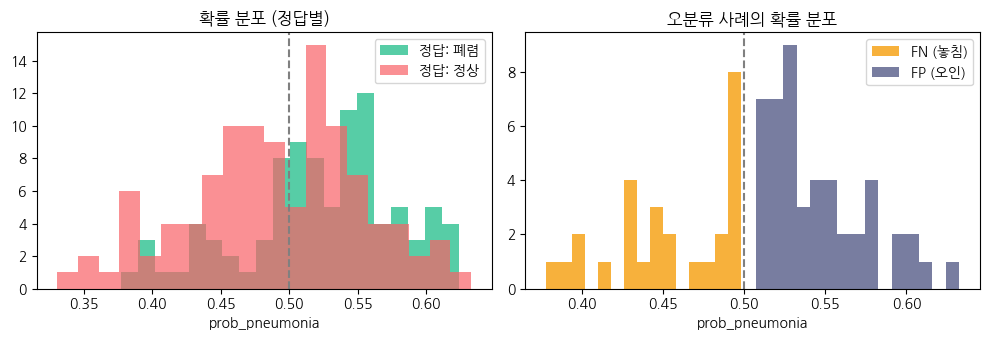

In [12]:
# ============================================================
# 1-3: 사례별 예측 확률 분포
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(preds_df.loc[preds_df['true']==1, 'prob_pneumonia'], bins=20, color='#10B981', alpha=0.7, label='정답: 폐렴')
axes[0].hist(preds_df.loc[preds_df['true']==0, 'prob_pneumonia'], bins=20, color='#F96167', alpha=0.7, label='정답: 정상')
axes[0].axvline(0.5, ls='--', c='gray'); axes[0].legend(); axes[0].set_title('확률 분포 (정답별)')
axes[0].set_xlabel('prob_pneumonia')

axes[1].hist(fn_df['prob_pneumonia'], bins=15, color='#F59E0B', alpha=0.8, label='FN (놓침)')
axes[1].hist(fp_df['prob_pneumonia'], bins=15, color='#1E2761', alpha=0.6, label='FP (오인)')
axes[1].axvline(0.5, ls='--', c='gray'); axes[1].legend(); axes[1].set_title('오분류 사례의 확률 분포')
axes[1].set_xlabel('prob_pneumonia')
plt.tight_layout(); plt.show()

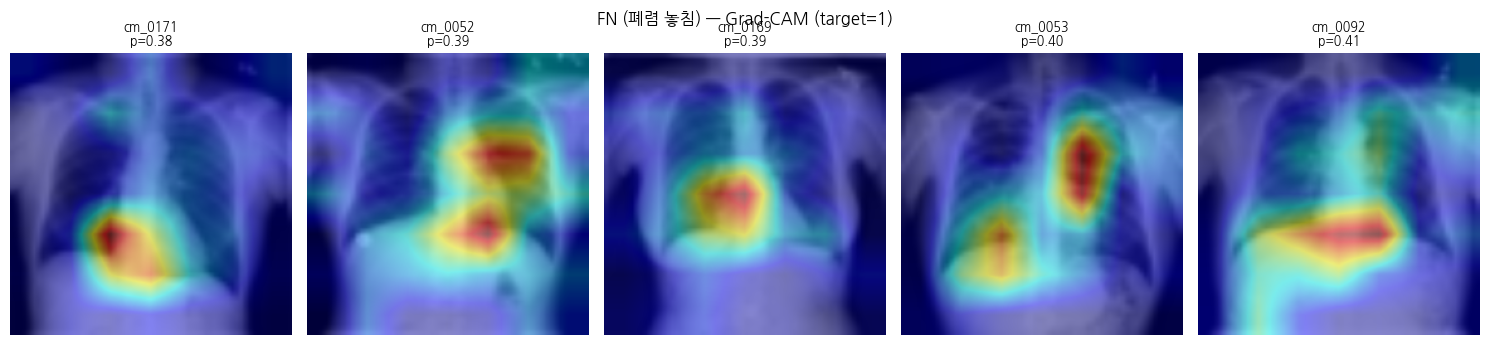

In [13]:
# ============================================================
# 1-4: FN 사례 Grad-CAM 일괄 적용 (상위 5장) - 폐렴을 놓친 FN 사례 5장
#  FN = 실제는 폐렴(1)인데 모델은 정상(0) 쪽으로 판단한 사례, p가 0.5보다 작음
# 제목의 target=1은: “폐렴이라고 판단하려면 어디를 봐야 했는가?”
# ============================================================
def overlay_cam(img_disp, cam, alpha=0.45):
    heat = cv2.applyColorMap((cam*255).astype(np.uint8), cv2.COLORMAP_JET)
    heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB) / 255.0
    base = np.stack([img_disp]*3, axis=-1)
    return (1-alpha)*base + alpha*heat

fn_sample = fn_df.head(5)
fig, axes = plt.subplots(1, 5, figsize=(15, 3.5))
for ax, (_, row) in zip(axes, fn_sample.iterrows()):
    t, d = load_image_224(row['image_id'])
    cam = gradcam_one(model, t, target_class=1, target_layer=model.layer4) #  target=1은: “폐렴이라고 판단하려면 어디를 봐야 했는가?”
    ax.imshow(overlay_cam(d, cam))
    ax.set_title(f"{row['image_id']}\np={row['prob_pneumonia']:.2f}", fontsize=9)
    ax.axis('off')
fig.suptitle('FN (폐렴 놓침) — Grad-CAM (target=1)')
plt.tight_layout(); plt.show()
# 빨강/노랑 = 폐렴 클래스 판단에 강하게 기여한 영역, 파랑 = 기여가 약한 영역

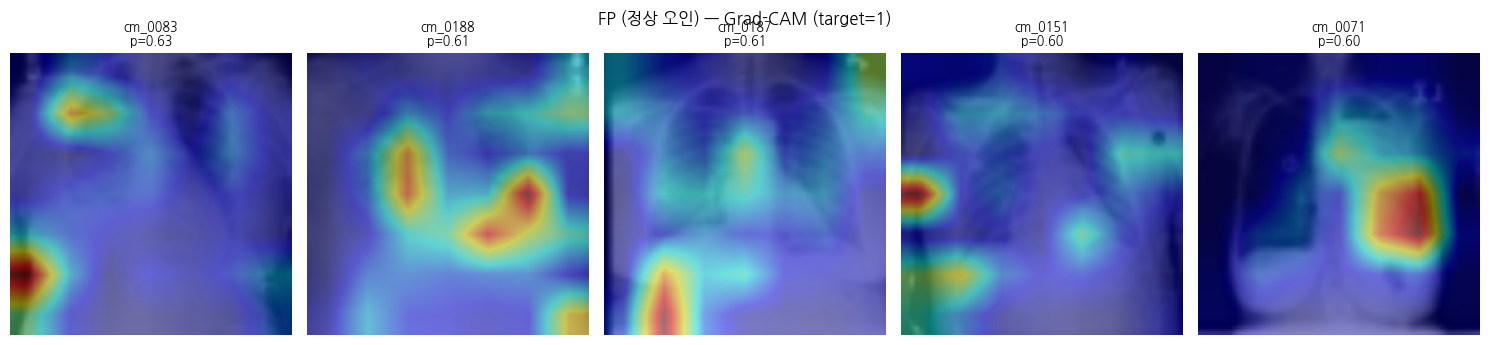

In [14]:
# ============================================================
# 1-5: FP 사례 Grad-CAM 일괄 적용 (상위 5장)
# FP (정상 오인) — Grad-CAM (target=1)
# 실제 = 정상(0), 예측 = 폐렴(1) 즉 p가 0.5보다 큼
# ============================================================
fp_sample = fp_df.head(5)
fig, axes = plt.subplots(1, 5, figsize=(15, 3.5))
for ax, (_, row) in zip(axes, fp_sample.iterrows()):
    t, d = load_image_224(row['image_id'])
    cam = gradcam_one(model, t, target_class=1, target_layer=model.layer4)
    ax.imshow(overlay_cam(d, cam))
    ax.set_title(f"{row['image_id']}\np={row['prob_pneumonia']:.2f}", fontsize=9)
    ax.axis('off')
fig.suptitle('FP (정상 오인) — Grad-CAM (target=1)')
plt.tight_layout(); plt.show()

### 💡 강사 토의 메모

- **FN 사례에서 attention이 폐 외곽이나 빈 공간에 있다면** → 모델이 폐를 안 봤다는 단서.
  단정 금지, 가설 수준.
- **FP 사례에서 attention이 의료기기·라벨에 강하게 있다면** → shortcut learning 의심.
- 다음 실습(1-B)에서 bbox annotation을 overlay하여 **임상 ROI와의 정합도**를 직접 본다.

> **핵심**: "맞춘 사례"는 모델을 칭찬할 근거가 약하다. 틀린 사례에서 모델의 약점이 드러난다.

---

# ✏️ 실습 1-B — 본인 사례 분석 + bbox 시각 비교 [수강생 실습]

**난이도**: ① 기본 → ② **사고형 (필수)** → ③ **(도전) 사고형**

| 과제 | 변경 포인트 | 확인할 것 |
|------|-----------|---------|
| ① | 흥미로운 오분류 사례 1장 선택 + Grad-CAM | 어디에 attention이 있는가 — 한 문장 메모 |
| ② **(사고형)** | FP/FN/정답 사례 각 2장씩에 bbox overlay + 3등급 자기 라벨링 | 정답·오답 일치도 패턴 차이 가설 |
| ③ **(도전, 사고형)** | Shortcut 가설 1줄 + 검증 실험 설계 1줄 | M4 SaMD·후속 강의 단서로 활용 |

> ⚠️ ②에서 사용하는 RSNA bbox 좌표계(좌상단 vs 중심 / 원본 vs 224×224)는
> **강의 직전 재확인** 필요. 본 노트북은 (x, y, width, height) 좌상단+크기, 224×224 좌표 가정.

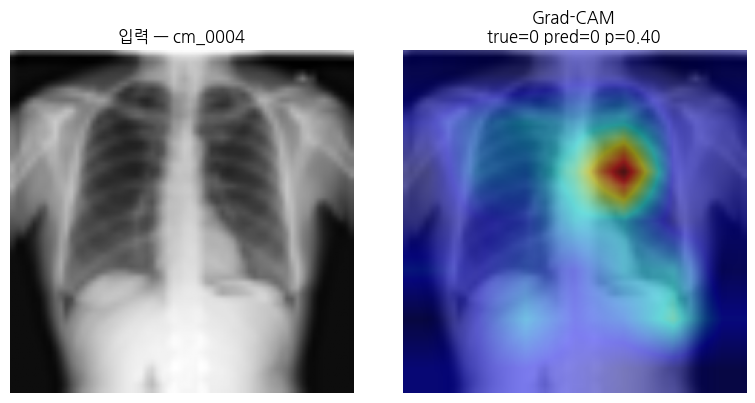

In [23]:
# ============================================================
# ✏️ 과제 ① — 흥미로운 오분류 사례 1장 선택
# ============================================================
# TODO 1: case_idx 에 본인이 보기에 가장 이상한 오분류 사례의 행 인덱스를 넣으세요.
# 힌트: fn_df / fp_df 에서 prob_pneumonia 가 0.5 부근인 행 또는 가장자리 값(0.0/1.0 근처)

case_idx = 4  # ✏️ 수정 TN

# ----- 아래 코드는 수정하지 마세요 -----
row = preds_df.iloc[case_idx]
t, d = load_image_224(row['image_id'])
_tgt = int(row['true']) if row['true'] != row['pred'] else 1
cam = gradcam_one(model, t, target_class=_tgt, target_layer=model.layer4)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(d, cmap='gray'); axes[0].set_title(f"입력 — {row['image_id']}"); axes[0].axis('off')
axes[1].imshow(overlay_cam(d, cam))
axes[1].set_title(f"Grad-CAM\ntrue={int(row['true'])} pred={int(row['pred'])} p={row['prob_pneumonia']:.2f}")
axes[1].axis('off')
plt.tight_layout(); plt.show()

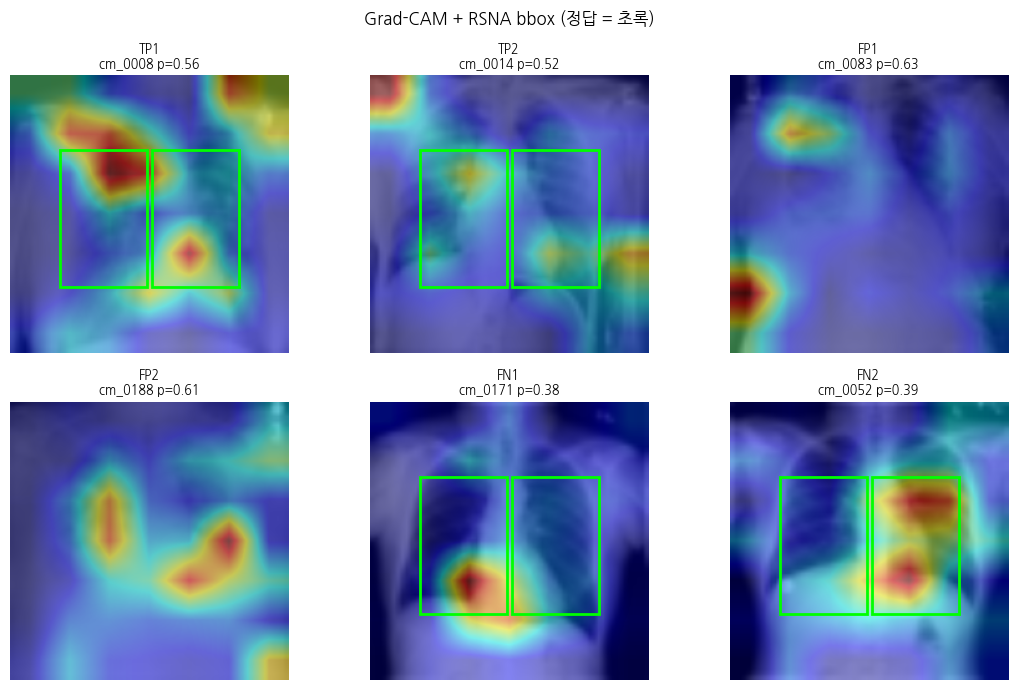

내 시각 라벨링: {'TP1': '일부 겹침', 'TP2': '읿부 겹침', 'FP1': '안 겹침', 'FP2': '안 겹침', 'FN1': '일부 겹침', 'FN2': '겹침'}


In [24]:
# ============================================================
# ✏️ 과제 ② (사고형) — FP/FN/정답 사례 각 2장씩 + bbox overlay
# ============================================================
def draw_with_bbox(ax, img, cam, bboxes, title):
    """ax: matplotlib axis  /  bboxes: [(x,y,w,h), ...]  (224 좌표계 가정)"""
    ax.imshow(overlay_cam(img, cam))
    for (x, y, w, h) in bboxes:
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)
    ax.set_title(title, fontsize=9); ax.axis('off')

def bboxes_of(image_id):
    rows = bbox_df[bbox_df['image_id'] == image_id]
    return [(r.x, r.y, r.width, r.height) for r in rows.itertuples()]

# 사례 6장 선택 — TP 2 / FP 2 / FN 2
picks = {
    'TP1': tp_mask[tp_mask].index[0] if tp_mask.any() else None,
    'TP2': tp_mask[tp_mask].index[1] if tp_mask.sum() >= 2 else None,
    'FP1': fp_df.index[0] if len(fp_df) >= 1 else None,
    'FP2': fp_df.index[1] if len(fp_df) >= 2 else None,
    'FN1': fn_df.index[0] if len(fn_df) >= 1 else None,
    'FN2': fn_df.index[1] if len(fn_df) >= 2 else None,
}
fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for ax, (name, idx) in zip(axes.flat, picks.items()):
    if idx is None: ax.axis('off'); continue
    row = preds_df.loc[idx]
    t, d = load_image_224(row['image_id'])
    cam = gradcam_one(model, t, target_class=1, target_layer=model.layer4)
    bb = bboxes_of(row['image_id'])  # 정답 폐렴 영상에만 bbox 존재
    draw_with_bbox(ax, d, cam, bb, f"{name}\n{row['image_id']} p={row['prob_pneumonia']:.2f}")
plt.suptitle('Grad-CAM + RSNA bbox (정답 = 초록)'); plt.tight_layout(); plt.show()

# TODO 2: 위 6장의 일치도를 본인이 3등급으로 자기 라벨링하세요
# 라벨은: '겹친다' / '일부 겹친다' / '안 겹친다' 중 하나

my_labels = {
    'TP1': '일부 겹침',  # ✏️ 수정
    'TP2': '읿부 겹침',  # ✏️ 수정
    'FP1': '안 겹침',  # ✏️ 수정
    'FP2': '안 겹침',  # ✏️ 수정
    'FN1': '일부 겹침',  # ✏️ 수정
    'FN2': '겹침',  # ✏️ 수정
}
print('내 시각 라벨링:', my_labels)

### 🤔 ② 사고형 — 본인 해석을 적어보세요 (수강생 작성)

위 6장의 결과를 보고 아래 3가지에 답하세요 (각 1~2 문장).

1. **정답(TP) 사례와 오분류(FP/FN) 사례의 일치도 패턴이 어떻게 다른가?**
   - (여기에 본인 관찰을 적으세요)

2. **Grad-CAM이 빗나간 사례의 공통점 가설 1줄**
   (병변 크기? 위치? 영상 품질? bbox annotation 노이즈?)
   - (가설:)

3. **"폐 전체가 광범위하게 빨개도 맞춘 것"인가? 본인 판단 기준 1줄**
   - (기준:)


### 🤔 ③ (도전, 사고형) — Shortcut 가설 + 검증 실험 설계

②에서 발견한 attention 패턴이 임상이 아닌 **비임상 단서**(검사 종류 마커,
영상 가장자리, 의료기기 흔적)에 가까운지 가설을 세워봅니다.

- **Shortcut 가설 1줄**: (가설을 적으세요)

- **검증 실험 설계 1줄**: (어떤 추가 실험이 필요한가? — 가설 검증은 본 실습에서 보장 안 됨)

> 후속 강의의 SaMD 평가·데이터 정제 단서로 활용됩니다.


---

## 📖 Part 2 — Sanity Check + Pointing Game

### Sanity Check 미니 실험 (Adebayo 2018)

**무작위 가중치 ResNet50**에 같은 입력으로 Grad-CAM을 적용한 결과가
학습된 모델의 결과와 비슷하면, saliency가 모델의 학습 정보를 반영한다는 증거가 약해진다.

### Pointing Game (정량 평가)

- Grad-CAM heatmap의 **argmax 좌표**를 찾는다.
- 그 좌표가 정답 **bbox 내부**에 들어가면 **hit** (1), 아니면 miss (0).
- 전체 양성 사례 N개에 대해 hit/N = **hit rate**.

```python
def pointing_hit(cam, bboxes):
    y, x = np.unravel_index(cam.argmax(), cam.shape)
    for (bx, by, bw, bh) in bboxes:
        if bx <= x <= bx + bw and by <= y <= by + bh:
            return 1
    return 0
```

> 정식 정의: Zhang et al., ECCV 2016 / IJCV 2018 — 본 실습은 단순화 버전.

---

# 🎯 실습 2 — Sanity Check 미니 실험 [강사 시연]

**목표**: 학습된 모델과 무작위 가중치 모델의 Grad-CAM을 시각 비교.

| 단계 | 내용 |
|------|------|
| 2-1 | 무작위 가중치 ResNet50 생성 |
| 2-2 | 같은 입력 3장에 Grad-CAM 적용 |
| 2-3 | 학습된 모델 결과와 좌우 비교 figure |
| 2-4 | 한계 명시 — 필요조건일 뿐 충분조건 아님 |

**결과물**: (학습된 모델 vs 무작위 모델) Grad-CAM 페어 비교 figure + 한 줄 결론

In [25]:
# ============================================================
# 2-1: 무작위 가중치 ResNet50 생성 (학습 안 한 모델)
# ============================================================
random_model = build_resnet50_binary().to(DEVICE)
random_model.eval()
print('✅ 무작위 가중치 모델 생성 — 학습/사전학습 모두 없음')
print(f'   파라미터: {sum(p.numel() for p in random_model.parameters()):,}')

✅ 무작위 가중치 모델 생성 — 학습/사전학습 모두 없음
   파라미터: 23,505,858


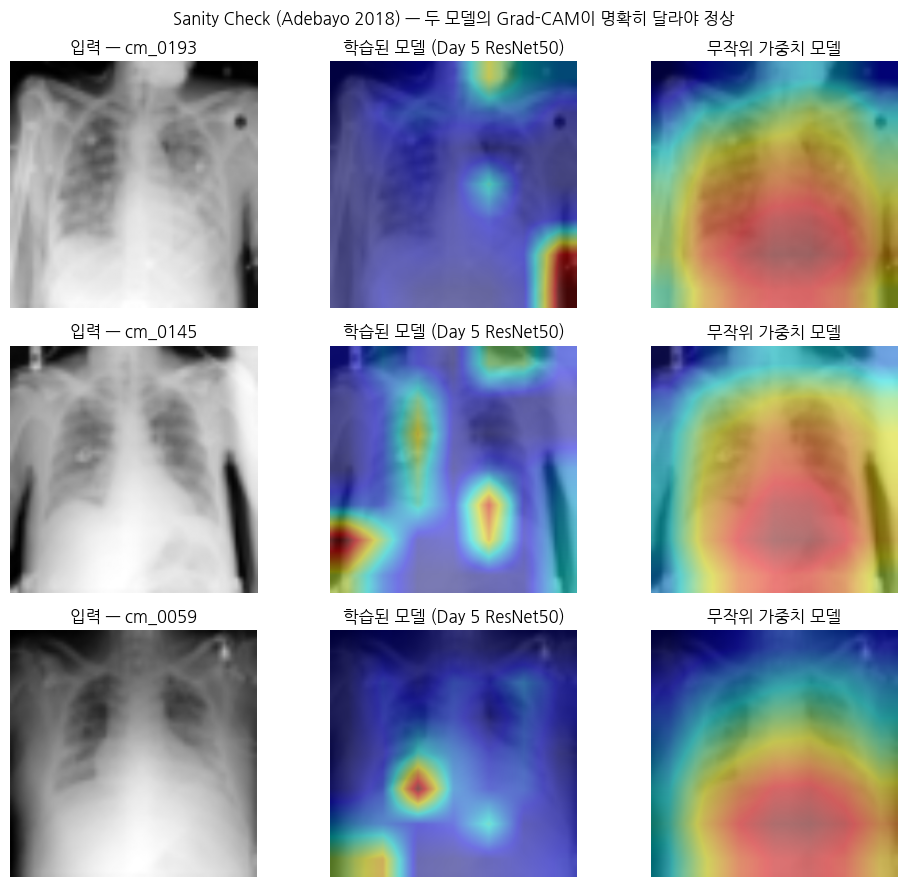

In [26]:
# ============================================================
# 2-2 ~ 2-3: 같은 입력 3장에 학습된 vs 무작위 Grad-CAM 비교
# ============================================================
# 폐렴 정답(TP) 중 prob_pneumonia가 높은 3장 선택
tp_top3 = preds_df[tp_mask].sort_values('prob_pneumonia', ascending=False).head(3)

fig, axes = plt.subplots(3, 3, figsize=(10, 9))
for i, (_, row) in enumerate(tp_top3.iterrows()):
    t, d = load_image_224(row['image_id'])
    cam_trained = gradcam_one(model,        t, target_class=1, target_layer=model.layer4)
    cam_random  = gradcam_one(random_model, t, target_class=1, target_layer=random_model.layer4)
    axes[i, 0].imshow(d, cmap='gray'); axes[i, 0].set_title(f"입력 — {row['image_id']}"); axes[i, 0].axis('off')
    axes[i, 1].imshow(overlay_cam(d, cam_trained)); axes[i, 1].set_title('학습된 모델 (Day 5 ResNet50)'); axes[i, 1].axis('off')
    axes[i, 2].imshow(overlay_cam(d, cam_random));  axes[i, 2].set_title('무작위 가중치 모델');           axes[i, 2].axis('off')
plt.suptitle('Sanity Check (Adebayo 2018) — 두 모델의 Grad-CAM이 명확히 달라야 정상')
plt.tight_layout(); plt.show()

### 💡 한계 명시 — 필요조건일 뿐 충분조건 아님

- ✅ **학습된 모델과 무작위 모델의 saliency가 명확히 다르다** → saliency가 모델 정보를 반영하는 **약한 증거**.
- ❌ **"다르다"가 "임상적으로 옳다"를 보장하지 않는다.** Shortcut을 학습한 모델도 무작위 모델과는 다른 saliency를 만든다.
- 임상 검증은 **bbox 비교 + Pointing Game + 외부 데이터 일반화** 같은 추가 단계로 보강해야 한다.

> Adebayo et al., "Sanity Checks for Saliency Maps", **NeurIPS 2018**.

---

# ✏️ 실습 2-B — Pointing Game 정량 평가 + 백본 비교 [수강생 실습]

**난이도**: ① **사고형 (필수)** → ② **사고형 (필수)** → ③ **(도전) 사고형**

| 과제 | 변경 포인트 | 확인할 것 |
|------|-----------|---------|
| ① **(사고형)** | **1-B 시각 라벨 vs Pointing hit (같은 사례)** + layer4 vs layer3 hit rate | 내 직관과 정량 지표가 같은 사례에서 일치하는가 |
| ② **(사고형)** | 정답 vs 오분류 그룹별 hit rate 비교 | "맞춘 것 = ROI를 본 것"이 참인가 |

In [27]:
# ============================================================
# 공통 함수 — Pointing Game hit rate
# ============================================================
def pointing_hit(cam, bboxes):
    """cam (H,W)의 argmax 좌표가 bbox 중 하나에 들어가면 1."""
    if not bboxes:
        return 0
    y, x = np.unravel_index(cam.argmax(), cam.shape)
    for (bx, by, bw, bh) in bboxes:
        if bx <= x <= bx + bw and by <= y <= by + bh:
            return 1
    return 0

def hit_rate(model_, df_subset, target_layer):
    """df_subset의 폐렴 양성 사례에 대해 hit rate 반환."""
    hits, total = 0, 0
    per_case = []
    for _, row in df_subset.iterrows():
        bb = bboxes_of(row['image_id'])
        if not bb:
            continue
        t, d = load_image_224(row['image_id'])
        cam = gradcam_one(model_, t, target_class=1, target_layer=target_layer)
        h = pointing_hit(cam, bb)
        per_case.append((row['image_id'], h))
        hits += h; total += 1
    return (hits / total if total > 0 else 0.0), per_case

print('✅ pointing_hit / hit_rate 정의 완료')

✅ pointing_hit / hit_rate 정의 완료


▼ 1-B 시각 라벨 vs Pointing Game hit (같은 사례, layer4)
case image_id visual (1-B) hit (Pointing)
 TP1  cm_0008        일부 겹침              ✅
 TP2  cm_0014        읿부 겹침              ❌
 FN1  cm_0171        일부 겹침              ✅
 FN2  cm_0052           겹침              ✅

Pointing Game — layer4: hit rate = 50.00%  (n=20)
Pointing Game — layer3: hit rate = 0.00%  (n=20)


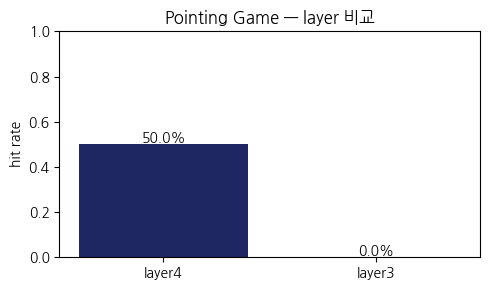

In [28]:
# ============================================================
# ✏️ 과제 ① (사고형) — 시각 라벨 vs hit (같은 사례) + layer 비교
# ============================================================

# ─── (a) 1-B 시각 라벨링 사례에 대한 Pointing hit ───────────────
# 1-B에서 picks(6장) + my_labels(시각 3등급)를 만들었다.
# Pointing Game은 bbox가 있는 양성 사례에서만 정의 → TP/FN만 비교.
compare_cases = {k: idx for k, idx in picks.items()
                 if idx is not None and k.startswith(('TP', 'FN'))}

records = []
for name, idx in compare_cases.items():
    row = preds_df.loc[idx]
    t, _ = load_image_224(row['image_id'])
    cam = gradcam_one(model, t, target_class=1, target_layer=model.layer4)
    bb = bboxes_of(row['image_id'])
    hit = pointing_hit(cam, bb)
    records.append({
        'case': name,
        'image_id': row['image_id'],
        'visual (1-B)': my_labels.get(name, '?'),
        'hit (Pointing)': '✅' if hit else '❌',
    })

compare_df = pd.DataFrame(records)
print('▼ 1-B 시각 라벨 vs Pointing Game hit (같은 사례, layer4)')
print(compare_df.to_string(index=False))

# ─── (b) 모집단 layer4 vs layer3 hit rate ─────────────────────
# 폐렴 양성 test set 상위 20장 (bbox 보유 가정)
pos_with_bbox = preds_df[preds_df['true'] == 1].head(20)

hr_l4, per_l4 = hit_rate(model, pos_with_bbox, target_layer=model.layer4)
hr_l3, per_l3 = hit_rate(model, pos_with_bbox, target_layer=model.layer3)

print(f'\nPointing Game — layer4: hit rate = {hr_l4:.2%}  (n={len(per_l4)})')
print(f'Pointing Game — layer3: hit rate = {hr_l3:.2%}  (n={len(per_l3)})')

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['layer4', 'layer3'], [hr_l4, hr_l3], color=['#1E2761', '#F96167'])
for i, v in enumerate([hr_l4, hr_l3]):
    ax.text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')
ax.set_ylim(0, 1); ax.set_ylabel('hit rate'); ax.set_title('Pointing Game — layer 비교')
plt.tight_layout(); plt.show()

### 🤔 ① 사고형 — 본인 해석 (수강생 작성)

(a) `compare_df` 표와 (b) layer 비교 결과를 보고 답하세요 (각 1~2 문장).

1. **(a) `compare_df`에서 시각 라벨과 Pointing hit가 *어긋난 사례*가 있는가? 그 어긋남이 무엇을 의미하는가?**
   - 힌트: hit rate는 `argmax(cam)` 한 점만 본다 — 분포가 ROI에 넓게 퍼졌어도 peak가 bbox 경계 1px 밖이면 ❌.
   - (관찰:)

2. **(b) layer4와 layer3 중 어느 쪽이 hit rate가 높은가? receptive field 관점에서 설명할 수 있나?**
   - (비교:)

3. **hit ❌ 사례 1장의 빗나간 이유 가설 1줄** (병변 크기? 위치? attention 분포의 두 봉우리?)
   - (가설:)


TP 그룹 hit rate: 40.00%
FN 그룹 hit rate: 66.67%
차이: -26.67%


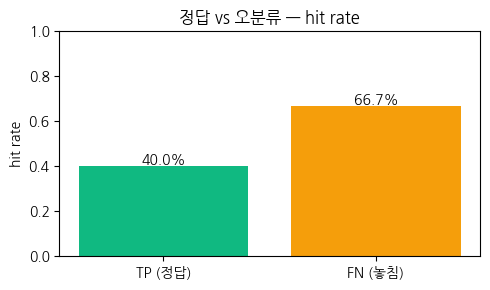

In [29]:
# ============================================================
# ✏️ 과제 ② (사고형) — 정답 vs 오분류 그룹별 hit rate
# ============================================================
# 분류가 맞은 폐렴(TP) vs 놓친 폐렴(FN) 각각의 hit rate 비교

tp_subset = preds_df[tp_mask].head(15)
fn_subset = preds_df[fn_mask].head(15)

hr_tp, _ = hit_rate(model, tp_subset, target_layer=model.layer4)
hr_fn, _ = hit_rate(model, fn_subset, target_layer=model.layer4)

print(f'TP 그룹 hit rate: {hr_tp:.2%}')
print(f'FN 그룹 hit rate: {hr_fn:.2%}')
print(f'차이: {(hr_tp - hr_fn):+.2%}')

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['TP (정답)', 'FN (놓침)'], [hr_tp, hr_fn], color=['#10B981', '#F59E0B'])
for i, v in enumerate([hr_tp, hr_fn]):
    ax.text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')
ax.set_ylim(0, 1); ax.set_ylabel('hit rate'); ax.set_title('정답 vs 오분류 — hit rate')
plt.tight_layout(); plt.show()

### 🤔 ② 사고형 — 본인 해석 (수강생 작성)

1. **TP 그룹이 FN 그룹보다 hit rate가 높은가?**
   - (관찰:)

2. **만약 FN 그룹의 hit rate가 의외로 높다면** — 그건 어떤 의미인가? ("ROI는 봤지만 다른 이유로 틀린 사례")
   - (해석:)

3. **"맞춘 사례 = ROI를 본 것" 이 항상 참인가? 한 줄 결론**
   - (결론:)


---

# 📋 정리 & 핵심 요약

## 스스로 점검해보기

1. ❓ **왜 "맞춘 사례"가 아니라 "틀린 사례"를 들여다보는가?**
   - 정답 분포에 묻혀 있던 edge case에서 모델 약점이 드러나기 때문.
   - FP/FN을 분리해 Grad-CAM을 적용하면 "어디를 보고 틀렸는가"를 시각화할 수 있음.

2. ❓ **Sanity Check가 "필요조건일 뿐 충분조건이 아니다"라는 말의 의미는?**
   - 무작위 모델과 saliency가 다르다고 그 saliency가 임상적으로 옳다는 보장은 없다.
   - 그러나 둘이 비슷하다면 그 saliency는 의심해야 한다 (Adebayo 2018).

3. ❓ **Pointing Game hit rate가 시각적 직관과 다를 수 있는 이유는?**
   - argmax 한 점만 보기 때문에 "넓게 분포한 attention"의 정합도는 반영 못 함.
   - 시각으로는 "일부 겹친다"여도 argmax가 bbox 밖이면 hit가 0.

## 핵심 코드 한 줄 요약

| 개념 | 코드 |
|------|------|
| FP/FN 분리 | `fp_mask = (df['true']==0) & (df['pred']==1)` |
| Grad-CAM++ 함수 | `gradcam_one(model, x, target_class, target_layer)` (내부: `pytorch_grad_cam.GradCAMPlusPlus`) |
| Sanity check | `random_model = build_resnet50_binary()` (학습 안 한 모델) |
| Pointing Game | `y,x = np.unravel_index(cam.argmax(), cam.shape)` |

## 다음 시간 예고

> 🍱 **점심 (13:15~14:15)** — 충전하고 오후 모듈로!
>
> **M3. U-Net 아키텍처와 구현 (14:15~)** — 분류는 끝났다. 오후엔 픽셀 단위 예측 = segmentation으로 넘어간다.
